### CIFAR-10 Classification with Mamba

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from cifar10_task import CIFAR10Task
from src.train_utils.trainer import Trainer
from src.utils.common import device_auto

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_mamba_block_cfg_ctor

In [4]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "CIFAR10" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 64,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permute": False,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 100,
    "lr": 1e-4,
    "wd": 1e-4,
    "grad_clip": 0.5,
    "amp": False,
    "save_dir": "./runs/cifar10_mamba_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 4,  # Checkpoint was trained with 4 layers
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # Mamba-specific parameters
    "d_state": 4,
    "expand_factor": 2,
    "d_conv": 4,
    "use_external_mlp": True,
}

args["block_cfg_ctor"] = make_mamba_block_cfg_ctor(**args)

args = device_auto(args)

Using MPS


### Training
With the configuration set up, we can now instantiate the `CIFAR10Task` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [5]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = CIFAR10Task()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

CIFAR-10 Loaders Created:
  Train: 50000 samples, 781 batches
  Test:  10000 samples, 157 batches
  Sequence length: 1024 (32×32)
  Input dim: 3 (RGB)
  Classes: 10
  Permutation: disabled
Loaded checkpoint from epoch 47
Val metrics: {'loss': 0.9906150756835937, 'time_s': 21.312375998008065, 'acc': 0.6829}


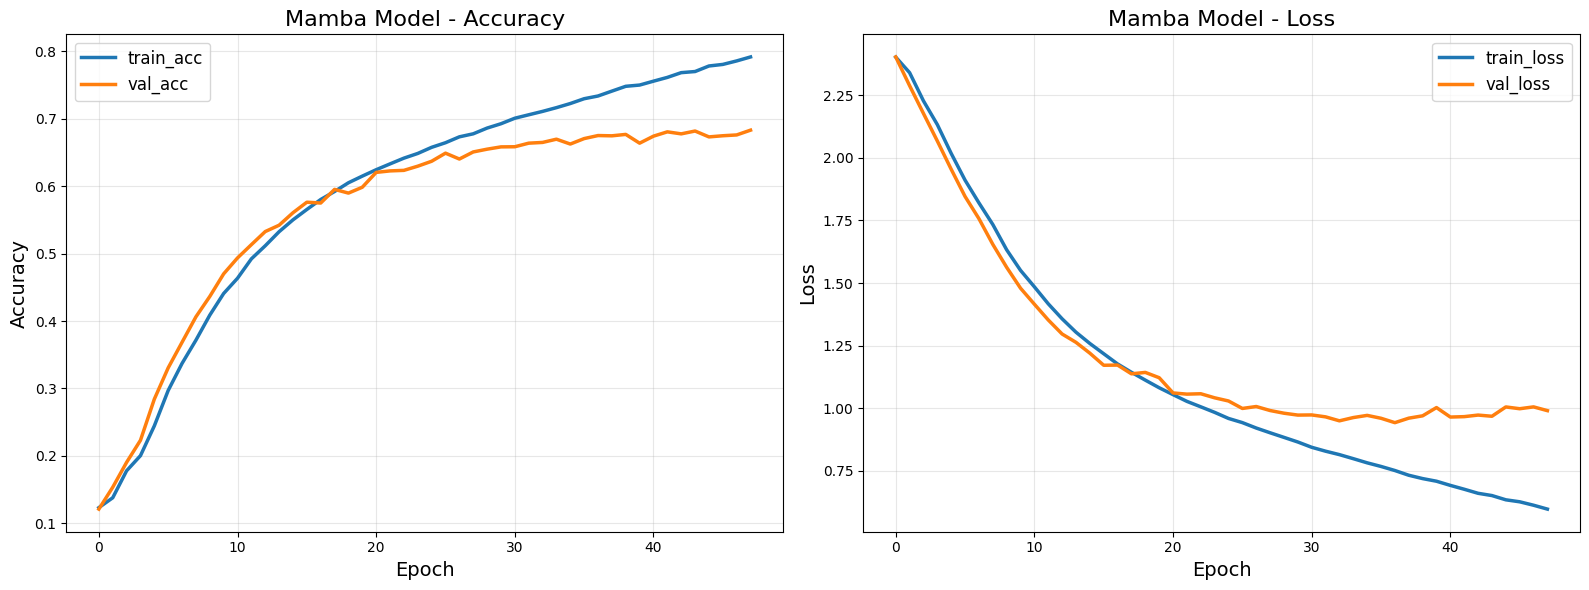


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: MambaCoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:                830,478
Trainable parameters:            830,478
Non-trainable parameters:              0
Model size (MB):                    3.17

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
proj                           Linear                                512
blocks                         ModuleLi

In [7]:
from src.utils.common import print_model_details
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=CIFAR10Task(),
)

history = trainer.history

plot_history(history, model_name="Mamba")

print_model_details(model=trainer.model)

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=CIFAR10Task(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Changes in dataset size

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/cifar10_mamba_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=CIFAR10Task())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="Mamba")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=CIFAR10Task(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )
